Import all libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

Prepare the dataset

mount the google drive to load the dataset

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# check the data directory
data_dir = Path("/content/drive/MyDrive/Dataset/BanglaLekha-Isolated/Images")
print(data_dir)
print("exists:", data_dir.exists())
print("is_dir:", data_dir.is_dir())

/content/drive/MyDrive/Dataset/BanglaLekha-Isolated/Images
exists: True
is_dir: True


In [ ]:
# set up data generators for training and testing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% test
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    color_mode='grayscale',
    batch_size=128,
    class_mode='categorical',
    subset='training'
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    color_mode='grayscale',
    batch_size=128,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
print("Total classes:", num_classes)

Found 5698 images belonging to 84 classes.
Found 1422 images belonging to 84 classes.
Total classes: 84


In [18]:
# Build the CNN model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Dropout,
                                     Dense, BatchNormalization, Reshape,
                                     Bidirectional, LSTM)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [19]:
input_shape = (64, 64, 1)

inputs = Input(shape=input_shape)

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.30)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.40)(x)

shape = x.shape
h, w, c = int(shape[1]), int(shape[2]), int(shape[3])
x = Reshape((w, h*c))(x)

x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Bidirectional(LSTM(128))(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 1024)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 8, 256)         │     1,180,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,24

 Total params: 1,951,540 (7.44 MB)

 Trainable params: 1,950,132 (7.44 MB)

 Non-trainable params: 1,408 (5.50 KB)

Train The model 

In [20]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 2124s 47s/step - accuracy: 0.7899 - loss: 1.0913 - val_accuracy: 0.2785 - val_loss: 3.5404
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 365ms/step - accuracy: 0.9535 - loss: 0.1802 - val_accuracy: 0.2785 - val_loss: 3.0545
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 354ms/step - accuracy: 0.9679 - loss: 0.1100 - val_accuracy: 0.2785 - val_loss: 2.6841
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 354ms/step - accuracy: 0.9740 - loss: 0.0922 - val_accuracy: 0.2785 - val_loss: 2.1659
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.9767 - loss: 0.0744 - val_accuracy: 0.2792 - val_loss: 2.6867


In [ ]:
# Evaluate the model on the test set
loss, acc = model.evaluate(test_generator)
print("Accuracy:", acc * 100)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.2792 - loss: 2.6867
Accuracy: 27.91842520236969


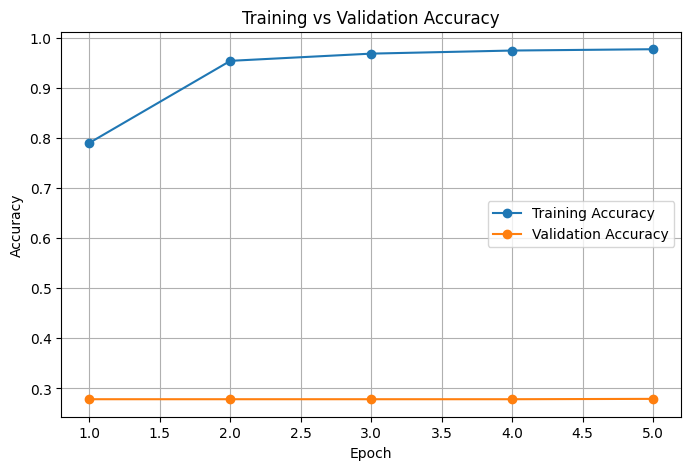

In [22]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

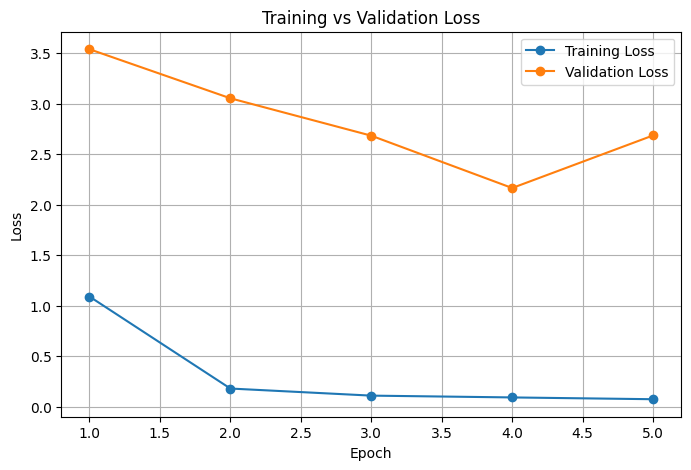

In [23]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


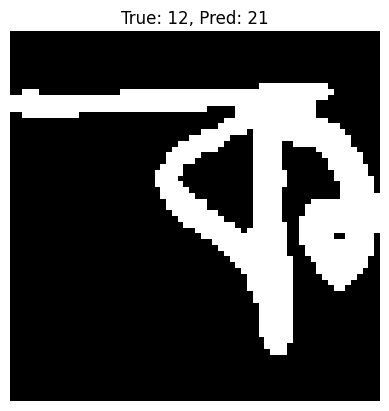

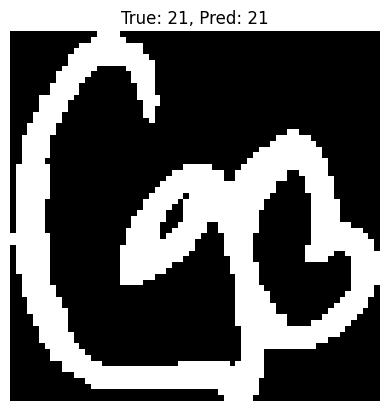

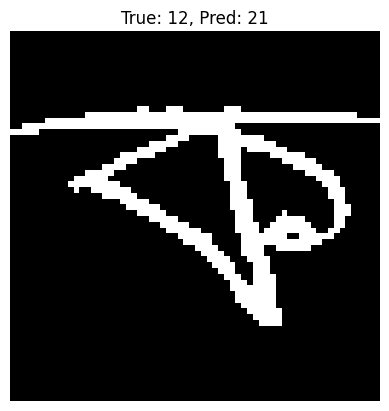

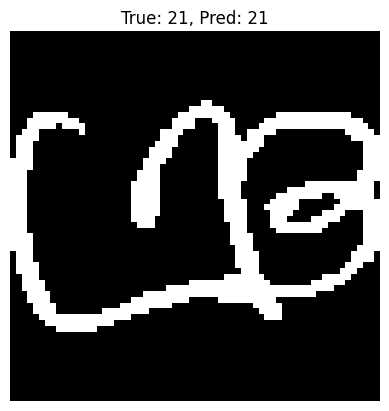

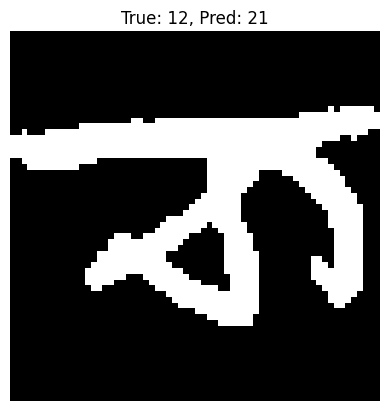

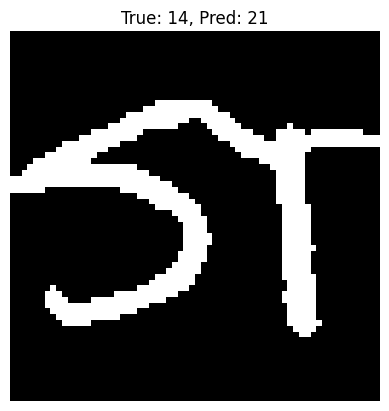

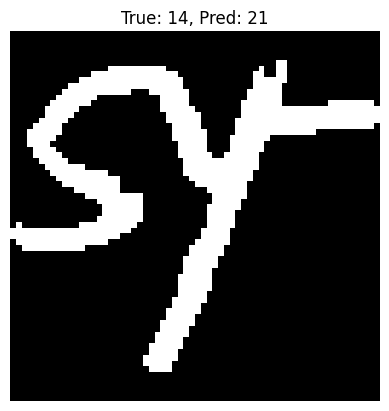

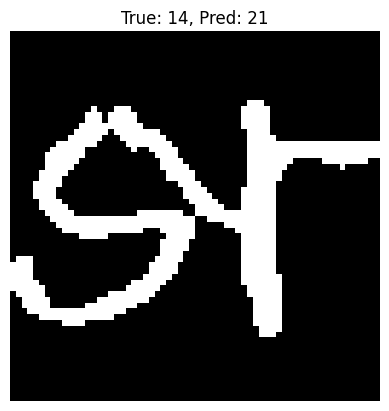

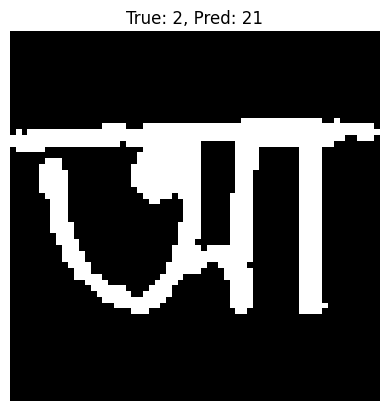

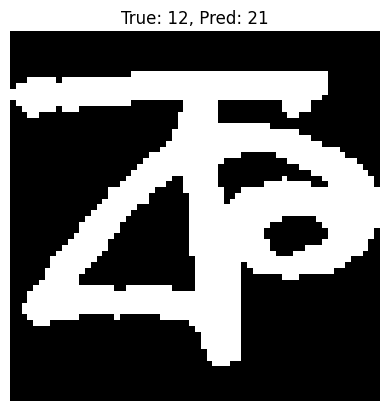

In [25]:
# test the model on a few samples from the test set
test_images, test_labels = next(test_generator)
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)
class_indices = train_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}

# see the first 10 predictions
for i in range(10):
    plt.imshow(test_images[i].reshape(64, 64), cmap='gray')
    plt.title(f"True: {inv_class_indices[true_classes[i]]}, Pred: {inv_class_indices[predicted_classes[i]]}")
    plt.axis('off')
    plt.show()
